In [21]:

import os
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Distance calculation
from math import radians, sin, cos, asin, sqrt
def haversine_vectorized(lon1, lat1, lon2, lat2):
    """Vectorized Haversine distance calculation (unit: km)"""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Earth's mean radius, km
    return c * r

# Global paths
INFO_CSV = "./typhoon_output/landfall_typhoons_info.csv"
TRACKS_CSV = "./typhoon_output/landfall_typhoons_tracks.csv"
PRE_BASE = "/mnt/home/lx/Databank/CHM_PRE_V2/daily"
OUTPUT_DIR = "./pre"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Typhoon wind categories (consistent with operational code)
def get_wind_category(wind_speed):
    if pd.isna(wind_speed) or wind_speed is None:
        return 0
    if wind_speed <= 17.1:    # TD
        return 0
    elif wind_speed <= 32.6:  # Storms
        return 1
    elif wind_speed < 51.0:   # TCs
        return 2
    else:                     # Super TCs
        return 3

# %% [markdown]
# ## 2. Load and Preprocess Typhoon Data

# %%
# Load landfall info table and generate 4-digit string ID
info_df = pd.read_csv(INFO_CSV)
info_df['code_str'] = info_df['chinese_code'].apply(lambda x: f"{x:04d}")

# Load track table, unify time format, generate 4-digit ID
tracks_df = pd.read_csv(TRACKS_CSV)
tracks_df['TIME'] = pd.to_datetime(tracks_df['TIME'])
tracks_df['code_str'] = tracks_df['chinese_code'].apply(lambda x: f"{x:04d}")
tracks_df['date'] = tracks_df['TIME'].dt.date

print(f"Total landfall typhoons: {len(info_df)}")
print(f"Total track points: {len(tracks_df)}")

# %% [markdown]
# ## 3. Define Typhoon Precipitation Extraction Function
# 
# This function processes a **single typhoon** by extracting daily precipitation based on its track points from the annual precipitation file and saves it as NetCDF.

# %%
def extract_typhoon_precip(code_str, tracks_df, pre_base, output_dir):
    """
    Extract precipitation field for a single typhoon and save it.
    
    Parameters
    ----------
    code_str : str
        4-digit typhoon ID, e.g., '0809'
    tracks_df : pd.DataFrame
        Global track table (already containing code_str column)
    pre_base : str
        Directory containing precipitation NetCDF files
    output_dir : str
        Output directory
    """
    out_file = Path(output_dir) / f"pre_{code_str}.nc"
    if out_file.exists():
        print(f"  Skipping: {code_str} already exists")
        return
    
    # Filter track points of this typhoon, sort by time
    typhoon_tracks = tracks_df[tracks_df['code_str'] == code_str].sort_values('TIME')
    if len(typhoon_tracks) == 0:
        print(f"  Warning: {code_str} has no track data, skipping")
        return
    
    # Determine the year from the ID (first two digits)
    year = int(code_str[:2])
    if 60 <= year <= 99:
        year += 1900
    elif 1 <= year <= 59:
        year += 2000
    elif year == 0:
        year = 2000
    else:
        print(f"  Error: cannot parse year for {code_str}")
        return
    
    # Read the annual precipitation file for that year
    pre_file = Path(pre_base) / f"CHM_PRE_V2_daily_{year}.nc"
    if not pre_file.exists():
        print(f"  Error: precipitation file {pre_file} does not exist")
        return
    
    ds_pre = xr.open_dataset(pre_file)
    # Extract lat/lon coordinates (assumed to be 1D)
    lats = ds_pre.lat.values
    lons = ds_pre.lon.values
    # Create 2D grids for distance calculation
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    # Dates during the typhoon's lifetime (deduplicated)
    dates = sorted(set(typhoon_tracks['date']))
    print(f"  Processing {code_str}: {len(dates)} days")
    
    # Estimate bounding box to reduce computation (speed up distance calculation)
    buffer = 6.0  # latitude-longitude buffer, ~600 km
    min_lat = max(typhoon_tracks['LAT'].min() - buffer, lats.min())
    max_lat = min(typhoon_tracks['LAT'].max() + buffer, lats.max())
    min_lon = max(typhoon_tracks['LONG'].min() - buffer, lons.min())
    max_lon = min(typhoon_tracks['LONG'].max() + buffer, lons.max())
    
    # Find index ranges of the bounding box in the grid
    lat_idx = np.where((lats >= min_lat) & (lats <= max_lat))[0]
    lon_idx = np.where((lons >= min_lon) & (lons <= max_lon))[0]
    if len(lat_idx) == 0 or len(lon_idx) == 0:
        lat_idx = slice(None)
        lon_idx = slice(None)
    else:
        lat_idx = slice(lat_idx[0], lat_idx[-1]+1)
        lon_idx = slice(lon_idx[0], lon_idx[-1]+1)
    
    # Extract sub-region grids
    sub_lats = lats[lat_idx]
    sub_lons = lons[lon_idx]
    sub_lon_grid, sub_lat_grid = np.meshgrid(sub_lons, sub_lats)
    
    # Store daily precipitation fields
    daily_precip_list = []
    valid_dates = []
    
    for day in dates:
        # Track points for the day
        day_points = typhoon_tracks[typhoon_tracks['date'] == day]
        if len(day_points) == 0:
            continue
        
        # Initialize mask: all sub-region grid points False
        mask = np.zeros(sub_lat_grid.shape, dtype=bool)
        
        # For each track point, compute distance and combine masks
        for _, row in day_points.iterrows():
            center_lon = row['LONG']
            center_lat = row['LAT']
            # Compute distances (km) from this center to all sub-region grid points
            dist = haversine_vectorized(center_lon, center_lat, sub_lon_grid, sub_lat_grid)
            mask |= (dist <= 500.0)  # 500 km radius
        
        # Read daily precipitation field (full grid)
        time_sel = ds_pre.time.where(ds_pre.time.dt.date == day, drop=True)
        if len(time_sel) == 0:
            # No precipitation data for this day (shouldn't happen for same year)
            continue
        daily_pre = ds_pre.prec.sel(time=time_sel.values[0])
        
        # Subset to sub-region and set outside mask to NaN
        daily_sub = daily_pre.isel(lat=lat_idx, lon=lon_idx).copy()
        daily_sub = daily_sub.where(mask)  # outside mask becomes NaN
        
        # Create a full-grid DataArray (all NaN) and fill in the sub-region
        full_array = xr.full_like(daily_pre, np.nan)
        full_array[lat_idx, lon_idx] = daily_sub
        
        # Add time dimension
        daily_da = full_array.expand_dims(time=[time_sel.values[0]])
        daily_precip_list.append(daily_da)
        valid_dates.append(time_sel.values[0])
    
    if len(daily_precip_list) == 0:
        print(f"  Warning: {code_str} has no valid precipitation days")
        return
    
    # Concatenate along time
    typhoon_precip = xr.concat(daily_precip_list, dim='time')
    
    # Build Dataset
    ds_out = xr.Dataset(
        {'prec': typhoon_precip},
        coords={
            'time': typhoon_precip.time,
            'lat': lats,
            'lon': lons
        }
    )
    # Copy original attributes
    ds_out.attrs = ds_pre.attrs.copy()
    ds_out.attrs['typhoon_code'] = code_str
    ds_out.attrs['creation_date'] = str(datetime.now())
    
    # Save to NetCDF
    ds_out.to_netcdf(out_file)
    print(f"  Done: {code_str} -> {out_file}")

# %% [markdown]
# ## 4. Batch Process All Landfall Typhoons

# %%
# Get all typhoon IDs to process (from landfall info table)
all_codes = info_df['code_str'].unique()
print(f"Total typhoons to process: {len(all_codes)}")

# Process one by one
for i, code in enumerate(all_codes):
    print(f"[{i+1}/{len(all_codes)}] Processing typhoon {code}")
    extract_typhoon_precip(code, tracks_df, PRE_BASE, OUTPUT_DIR)

print("\nAll typhoon precipitation extraction complete!")





Total landfall typhoons: 490
Total track points: 16526
Total typhoons to process: 490
[1/490] Processing typhoon 6001
  Processing 6001: 16 days
  Done: 6001 -> pre/pre_6001.nc
[2/490] Processing typhoon 6005
  Processing 6005: 16 days
  Done: 6005 -> pre/pre_6005.nc
[3/490] Processing typhoon 6007
  Processing 6007: 11 days
  Done: 6007 -> pre/pre_6007.nc
[4/490] Processing typhoon 6008
  Processing 6008: 13 days
  Done: 6008 -> pre/pre_6008.nc
[5/490] Processing typhoon 6012
  Processing 6012: 6 days
  Done: 6012 -> pre/pre_6012.nc
[6/490] Processing typhoon 6014
  Processing 6014: 12 days
  Done: 6014 -> pre/pre_6014.nc
[7/490] Processing typhoon 6016
  Processing 6016: 10 days
  Done: 6016 -> pre/pre_6016.nc
[8/490] Processing typhoon 6024
  Processing 6024: 15 days
  Done: 6024 -> pre/pre_6024.nc
[9/490] Processing typhoon 6103
  Processing 6103: 9 days
  Done: 6103 -> pre/pre_6103.nc
[10/490] Processing typhoon 6104
  Processing 6104: 12 days
  Done: 6104 -> pre/pre_6104.nc
[11/4

Loaded 16526 track points.

Inspecting file: pre/pre_9215.nc
<xarray.Dataset>
Dimensions:  (time: 17, lat: 360, lon: 640)
Coordinates:
  * time     (time) datetime64[ns] 1992-08-23 1992-08-24 ... 1992-09-08
  * lat      (lat) float64 18.05 18.15 18.25 18.35 ... 53.65 53.75 53.85 53.95
  * lon      (lon) float64 72.05 72.15 72.25 72.35 ... 135.7 135.8 135.8 135.9
Data variables:
    prec     (time, lat, lon) float64 ...
Attributes: (12/14)
    Title:               CHM_PRE V2: An upgraded high-precision gridded preci...
    Institution:         Data held at Faculty of Geographical Science, Beijin...
    History:             Last updated on July 02, 2025
    Reference1:          Information on the data is available at https://doi....
    Reference2:          All data is available at https://doi.org/10.5281/zen...
    Time_scale:          1960-01-01 to 2024-12-31
    ...                  ...
    Spatial_resolution:  0.1 degree
    Version:             V2.1
    Data_producer:       Jinlong 

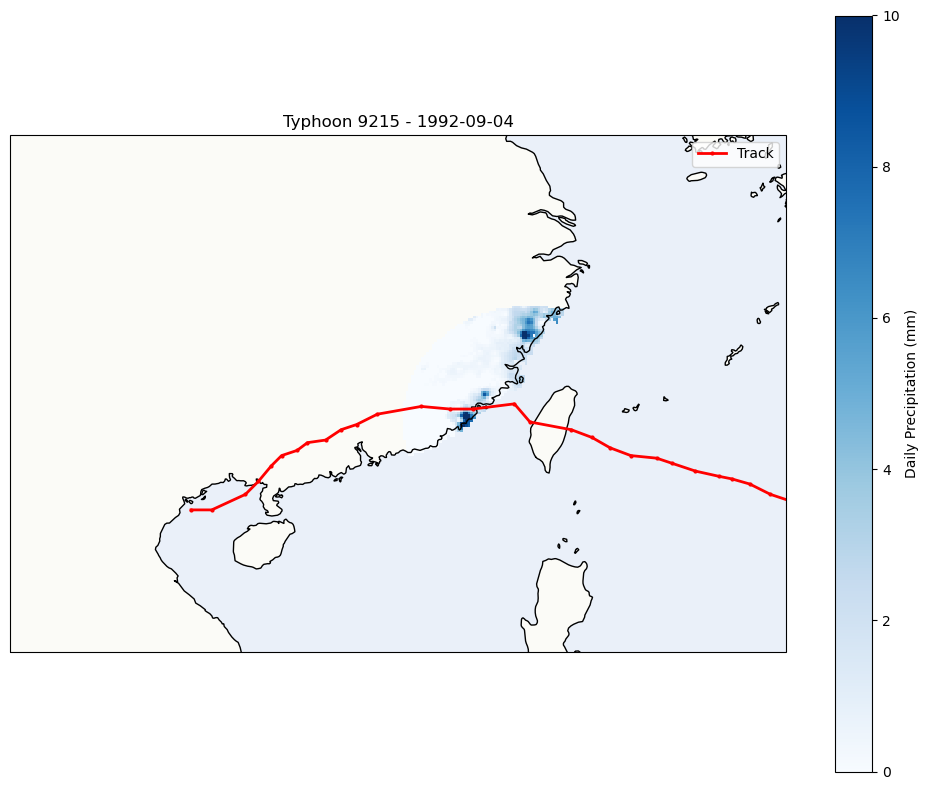

In [28]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

# ---------- Configuration ----------
TRACKS_PATH = 'typhoon_output/landfall_typhoons_tracks.csv'   # path to typhoon track CSV
OUTPUT_DIR = './pre'                                         # directory containing pre_*.nc files
TARGET_TYPHOON = '9215'                                    

# ---------- Load track data ----------
if not os.path.exists(TRACKS_PATH):
    raise FileNotFoundError(f"Track file not found: {TRACKS_PATH}. Please update TRACKS_PATH.")
tracks_df = pd.read_csv(TRACKS_PATH, dtype={'chinese_code': str})
tracks_df['TIME'] = pd.to_datetime(tracks_df['TIME'])
print(f"Loaded {len(tracks_df)} track points.")

# ---------- Locate the precipitation file ----------
precip_file = Path(OUTPUT_DIR) / f"pre_{TARGET_TYPHOON}.nc"
if not precip_file.exists():
    raise FileNotFoundError(f"Precipitation file not found: {precip_file}")

print(f"\nInspecting file: {precip_file}")
ds_sample = xr.open_dataset(precip_file)
print(ds_sample)

# ---------- Get track for this typhoon ----------
typhoon_code = TARGET_TYPHOON   # directly use the fixed code
typhoon_path = tracks_df[tracks_df['chinese_code'] == typhoon_code]
if len(typhoon_path) == 0:
    print(f"Warning: No track data found for typhoon {typhoon_code}")

# ---------- Choose a time step with valid precipitation ----------
valid_times = ds_sample.time.where(~ds_sample.prec.isnull().all(dim=('lat', 'lon')), drop=True)
if len(valid_times) == 0:
    print("No non‑NaN precipitation days exist in this typhoon file.")
else:
    # Try to find a time with at least some non-NaN values
    precip_t = None
    chosen_t = None
    for t in valid_times.values:
        temp = ds_sample.prec.sel(time=t)
        if not np.all(np.isnan(temp.values)):
            precip_t = temp
            chosen_t = t
            break
    if precip_t is None:
        print("All valid time steps still contain only NaN (unexpected).")
    else:
        # ---------- Plot ----------
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        ax.set_extent([100, 130, 15, 35], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.LAND, alpha=0.2)
        ax.add_feature(cfeature.OCEAN, alpha=0.2)

        # Plot precipitation
        im = precip_t.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(),
                                      cmap='Blues', add_colorbar=False,
                                      vmin=0, vmax=10)
        plt.colorbar(im, ax=ax, label='Daily Precipitation (mm)')

        # Overlay typhoon track
        if len(typhoon_path) > 0:
            ax.plot(typhoon_path['LONG'], typhoon_path['LAT'],
                    color='red', marker='o', markersize=2, linewidth=2,
                    transform=ccrs.PlateCarree(), label='Track')
            ax.legend()

        ax.set_title(f'Typhoon {typhoon_code} - {pd.to_datetime(chosen_t).strftime("%Y-%m-%d")}')
        plt.tight_layout()
        plt.show()

ds_sample.close()